In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from numba import njit , prange
from matplotlib.colors import TwoSlopeNorm
import progressbar
import hints
from itertools import permutations
import matplotlib.gridspec as gridspec
import matplotlib
from matplotlib.ticker import AutoMinorLocator
from scipy.io import loadmat
import glob
import imageio.v2 as imageio
import scipy
from statsmodels.tsa.stattools import adfuller
from scipy.stats import wilcoxon
import thesis
from matplotlib.ticker import MultipleLocator, MaxNLocator

def ReadEU4():
    folder="Synchronised measurements/"
    FIN_AU = pd.read_csv(folder+'finland_AU.csv.zip', index_col=0)
    NOR_NTUN = pd.read_csv(folder+'norway_NTNU.csv.zip', index_col=0)
    SWE_LTH = pd.read_csv(folder+'sweden_LTH.csv.zip', index_col=0)
    SWE_LTU = pd.read_csv(folder+'sweden_LTU.csv.zip', index_col=0)

    FIN_AU['date']=FIN_AU.index
    NOR_NTUN['date']=NOR_NTUN.index
    SWE_LTH['date']=SWE_LTH.index
    SWE_LTU['date']=SWE_LTU.index


    FIN_AU.rename(columns = {'Frequency':'FIN_AU'}, inplace = True)
    NOR_NTUN.rename(columns = {'Frequency':'NOR_NTUN'}, inplace = True)
    SWE_LTH.rename(columns = {'Frequency':'SWE_LTH'}, inplace = True)
    SWE_LTU.rename(columns = {'Frequency':'SWE_LTU'}, inplace = True)

    FIN_AU=FIN_AU[['date',"FIN_AU"]]
    NOR_NTUN=NOR_NTUN[['date',"NOR_NTUN"]]
    SWE_LTH=SWE_LTH[['date',"SWE_LTH"]]
    SWE_LTU=SWE_LTU[['date',"SWE_LTU"]]

    FIN_AU.reset_index(drop=True, inplace=True)
    NOR_NTUN.reset_index(drop=True, inplace=True)
    SWE_LTH.reset_index(drop=True, inplace=True)
    SWE_LTU.reset_index(drop=True, inplace=True)

    EU4 = pd.merge(FIN_AU, NOR_NTUN, on='date', how='inner')
    EU4 = pd.merge(EU4, SWE_LTH, on='date', how='inner')
    EU4 = pd.merge(EU4, SWE_LTU, on='date', how='inner')

    dates = EU4['date']

    EU4.drop('date',inplace=True,axis=1)
    EU4=EU4.to_numpy()
    EU4=np.swapaxes(EU4,0,1)

    cols_with_nan = np.isnan(EU4).any(axis=0)
    EU4 = EU4[:, ~cols_with_nan]

    np.save(folder+"EU4.npy",EU4)
    dates.to_csv(folder+"EU4_dates.csv", index=False)

def LoadEU4():
    folder="Synchronised measurements/"
    EU4=np.load(folder+"EU4.npy")
    dates = pd.read_csv(folder+"EU4_dates.csv")
    dates['date'] = pd.to_datetime(dates['date']) 
    npdates=dates['date'].dt.strftime('%Y-%m-%d %H:%M:%S').to_numpy()     # .%f    
    return EU4, dates, npdates 

@njit(parallel=True)
def localnorm( nl, data):
    newdata=np.zeros((data.shape[0],int(data.shape[1]-nl)))
    for i in prange(data.shape[0]):
        for j in range(nl, data.shape[1]):  
            newdata[i,j-nl] = (data[i,j] - np.mean(data[i,j-nl:j])) / np.std(data[i,j-nl:j])
    return newdata

def CheckStopCondition(X, bins, exponents):
    labels = ["FIN_AU", "FIN_TTY", "NOR_NTUN", "SWE_CTH", "SWE_KTH", "SWE_LTH", "SWE_LTU"]
    fig, axes = plt.subplots(len(exponents), 7, figsize=(28, 12), sharex='col')

    for dim in range(7):
        x = X[dim, :]
        counts, edges = np.histogram(x, bins=bins, density=True)
        centers = 0.5 * (edges[1:] + edges[:-1])
        pdf = counts

        # approximate standard error for histogram
        N = len(x)
        pdf_err = np.sqrt(counts * (1 - counts/np.sum(counts))) / np.sqrt(N)

        for i, k in enumerate(exponents[::-1]):  # reverse order like your figure
            ax = axes[i, dim]
            y = (centers**k) * pdf
            y_err = (centers**k) * pdf_err

            ax.errorbar(centers, y, yerr=y_err, fmt='o', color='black', markersize=2)
            ax.plot(centers, y, color='red')

            if dim == 0:
                ax.set_ylabel(r"$x^{%d}p(x)$" % k, fontsize=12)

            if i == 0:
                # ax.set_title(f"Dim {dim+1}")  # column titles
                ax.set_title(labels[dim], fontsize=12)

            if i == len(exponents) - 1:
                ax.set_xlabel("x")

    plt.tight_layout()
    plt.show()

def Wilcoxon(x,alpha,LAG_range):
    p_values = [] # Store p-values for each lag
    # Step 2: Iterate over the lag range and calculate p-values
    # Iterate over the lag range and calculate p-values
    for LAG in LAG_range:
        indices = np.arange(0, len(x), LAG)  # Generate indices with step size LAG
        variable_data = x[indices]  # Sample data at given lag
        variable_data = variable_data - np.mean(variable_data)  # Remove the mean
        
        # Factorize the data (like R's factor())
        labels = pd.factorize(variable_data)[0]
        differences = np.diff(labels)  # Calculate differences

        # Ensure no NaN values in differences
        differences = differences[~np.isnan(differences)]
        
        # Perform Wilcoxon test if differences have enough data
        if len(differences) > 0:
            p_value = wilcoxon(differences).pvalue
            p_values.append(p_value)
        else:
            p_values.append(1.0)  # Assign a high p-value if no valid test is possible

    # Step 3: Plot the p-values against LAG_range
    plt.plot(LAG_range, p_values, 'o')
    plt.axhline(y=alpha, color='red', linestyle='--')
    plt.xlabel('Lag')
    plt.ylabel('P-Value')
    plt.ylim(0, 1)
    plt.show()

    # Step 4: Find the first LAG where p-value <= alpha
    significant_lag_index = np.where(np.array(p_values) <= alpha)[0]

    if len(significant_lag_index) == 0:
        print("Data is not Markov for the chosen time lags!")
    else:
        significant_lag = LAG_range[significant_lag_index[0]]
        p_value_at_significant_lag = p_values[significant_lag_index[0]]
        
        # Highlight the point in the plot
        plt.plot(LAG_range, p_values, 'o')
        plt.axhline(y=alpha, color='red', linestyle='--')
        plt.scatter(significant_lag, p_value_at_significant_lag, color='red', s=100, lw=3)
        plt.xlabel('Lag')
        plt.ylabel('P-Value')
        plt.ylim(0, 1)
        plt.show()
        
        print(f"Data is Markov for time lag = {significant_lag}")
        print(f"with P-Value: = {p_value_at_significant_lag}")

def adf_test(series: pd.Series, significance: float = 0.05) -> dict:
    clean_series = series.dropna()
    if clean_series.nunique() <= 1:
        raise ValueError("The series must contain more than one unique value.")
    statistic, p_value, lags, observations, critical_values, *_ = adfuller(clean_series, autolag="AIC")
    stationary = p_value <= significance
    print(f"ADF statistic: {statistic:.4f}")
    print(f"p-value: {p_value:.4f}")
    print(f"Stationary at {significance:.0%}: {stationary}")
    return {        "statistic": statistic,        "p_value": p_value,        "lags": lags,        "observations": observations,        "critical_values": critical_values,        "stationary": stationary    }

def plot_nordic_timeseries(    X,    fs=50,    start_min=0,    duration_min=30,    skip=5,    save_path="Nordic_timeseries.pdf"):
    """
    X must have shape (4, number_of_samples).

    start_min  : beginning of the displayed segment, measured from
                  the start of the recording
    duration_min: duration of the displayed segment in minutes
    skip        : plot every skip-th data point
    """

    labels = ["FIN--AU", "NOR--NTNU", "SWE--LTH", "SWE--LU"]
    colors = ["blue", "orange", "green", "red"]
    panel_labels = ["a", "b", "c", "d"]

    start = int(start_min * 60 * fs)
    end = start + int(duration_min * 60 * fs)

    if end > X.shape[1]:
        raise ValueError("The selected interval exceeds the available data.")

    # Indices of the plotted data points
    indices = np.arange(start, end, skip)

    # Exact elapsed time from the beginning of the recording
    time_mins = indices / (fs * 60)

    with plt.rc_context({
        "text.usetex": True,
        "pgf.texsystem": "pdflatex",
        "font.family": "serif",
        "font.serif": ["Computer Modern"],
        "font.size": 14,
        "axes.labelsize": 16,
        "xtick.labelsize": 13,
        "ytick.labelsize": 13,
        "text.latex.preamble": r"\usepackage{amsmath}",
    }):

        fig, axes = plt.subplots(            4,            1,            figsize=(18, 10),            sharex=True,            gridspec_kw={"hspace": 0.08}        )
        for i, ax in enumerate(axes):
            ax.plot(                time_mins,                X[i, indices],                color=colors[i],                linewidth=0.7            )
            ax.set_xlim(-0.02*duration_min, 1.02*duration_min)
            ax.set_ylabel(rf"$x_{i+1}$")
            ax.text(                -0.015,                1.05,                panel_labels[i],                transform=ax.transAxes,                fontsize=22,                va="top",                ha="right"            )
            # ax.text(                0.99,                0.86,                labels[i],                transform=ax.transAxes,                fontsize=14,                va="top",                ha="right"            )
            # ax.set_xlim(time_mins[0], time_mins[-1])
            ax.tick_params(direction="in")

        axes[-1].set_xlabel(r"Time (min)")
        fig.align_ylabels(axes)
        plt.savefig(            save_path,            dpi=600,            bbox_inches="tight"        )
        plt.show()

dt=0.02


In [ ]:
ReadEU4()
EU4, dates, npdates = LoadEU4()
nl=10000
EU42=localnorm(nl, EU4)

In [5]:
series = EU42[0, :500000]
result = adfuller(series, autolag="AIC")
print(f"ADF statistic: {result[0]:.4f}")
print(f"p-value:       {result[1]:.4f}")
print(f"Lags used:     {result[2]}")
print(f"Observations:  {result[3]}")
print("Critical values:")
for level, value in result[4].items():
    print(f"  {level}: {value:.4f}")

ADF statistic: -9.4685
p-value:       0.0000
Lags used:     101
Observations:  499898
Critical values:
  1%: -3.4304
  5%: -2.8615
  10%: -2.5668


In [5]:
series = EU42[1, :500000]
result = adfuller(series, autolag="AIC")
print(f"ADF statistic: {result[0]:.4f}")
print(f"p-value:       {result[1]:.4f}")
print(f"Lags used:     {result[2]}")
print(f"Observations:  {result[3]}")
print("Critical values:")
for level, value in result[4].items():
    print(f"  {level}: {value:.4f}")

ADF statistic: -15.1167
p-value:       0.0000
Lags used:     101
Observations:  499898
Critical values:
  1%: -3.4304
  5%: -2.8615
  10%: -2.5668


In [6]:
series = EU42[2, :500000]
result = adfuller(series, autolag="AIC")
print(f"ADF statistic: {result[0]:.4f}")
print(f"p-value:       {result[1]:.4f}")
print(f"Lags used:     {result[2]}")
print(f"Observations:  {result[3]}")
print("Critical values:")
for level, value in result[4].items():
    print(f"  {level}: {value:.4f}")

ADF statistic: -12.0717
p-value:       0.0000
Lags used:     101
Observations:  499898
Critical values:
  1%: -3.4304
  5%: -2.8615
  10%: -2.5668


In [7]:
series = EU42[3, :500000]
result = adfuller(series, autolag="AIC")
print(f"ADF statistic: {result[0]:.4f}")
print(f"p-value:       {result[1]:.4f}")
print(f"Lags used:     {result[2]}")
print(f"Observations:  {result[3]}")
print("Critical values:")
for level, value in result[4].items():
    print(f"  {level}: {value:.4f}")

ADF statistic: -12.6711
p-value:       0.0000
Lags used:     101
Observations:  499898
Critical values:
  1%: -3.4304
  5%: -2.8615
  10%: -2.5668


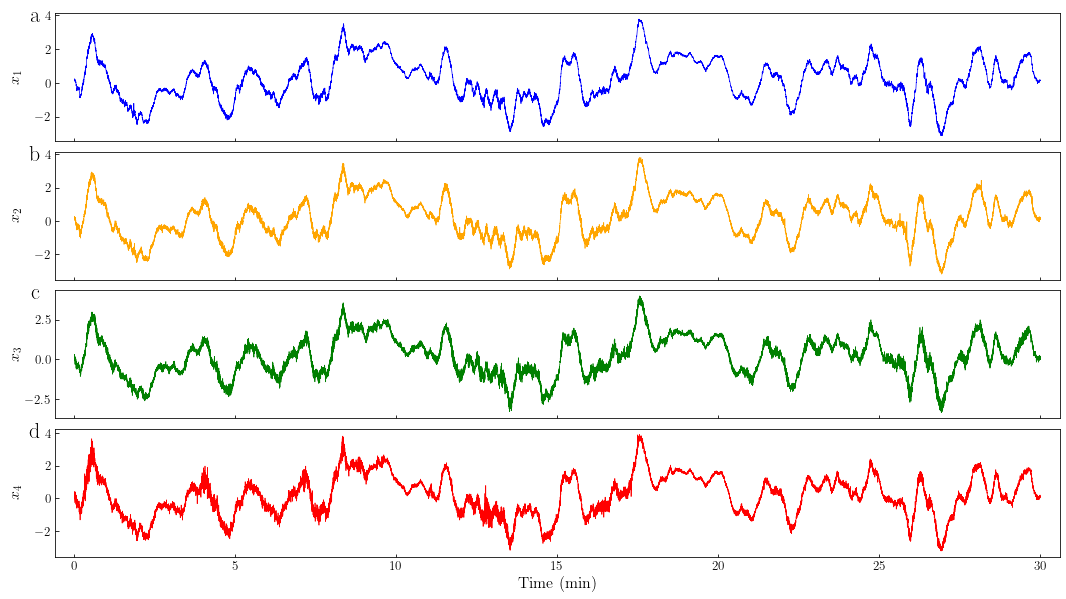

In [35]:
plot_nordic_timeseries(EU42)

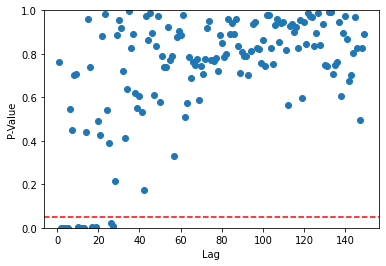

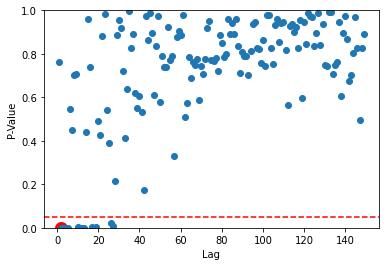

Data is Markov for time lag = 2
with P-Value: = 1.7990821311038098e-83


In [36]:
alpha = 0.05  # Significance level
LAG_range = np.arange(1, 150, 1)  # Set range of needed lags

Wilcoxon(EU7[5, :],alpha,LAG_range)

In [39]:
dt=0.02
x=np.copy(EU42)
l=1
N=4
M=1
mode="lim"
x,y=thesis.caly(x,N)
Dl1m1,ind,col=thesis.calDlcoef(l,x,y,dt,N,M,mode)
Dl1m1

,M₁1,M₁2,M₁3,M₁4
1,0.001395,-0.016215,0.001121,-0.001104
x1^1,-4.431362,7.212057,19.778213,35.360533
x2^1,0.698577,-13.301298,2.106737,1.778912
x3^1,1.541384,2.749995,-28.965606,4.570656
x4^1,2.204440,3.117730,6.842512,-41.928643


In [43]:
dt=0.02
x=np.copy(EU42)
l=2
N=4
M=0
mode="lim"
x,y=thesis.caly(x,N)
Dl2m0,ind,col=thesis.calDlcoef(l,x,y,dt,N,M,mode)
Dl2m0

,M₂11,M₂12,M₂13,M₂14,M₂22,M₂23,M₂24,M₂33,M₂34,M₂44
1,0.098946,0.006836,-0.004362,-0.034398,1.161625,0.027296,-0.016732,1.35894,0.018053,1.329362


In [44]:
dt=0.02
x=np.copy(EU42)
l=4
N=4
M=0
mode="lim"
x,y=thesis.caly(x,N)
Dl4m0,ind,col=thesis.calDlcoef(l,x,y,dt,N,M,mode)
Dl4m0

,M₄1111,M₄1122,M₄1133,M₄1144,M₄2222,M₄2233,M₄2244,M₄3333,M₄3344,M₄4444
1,0.560116,0.002923,0.003425,0.00504,0.496126,0.037926,0.040351,0.299032,0.045273,0.490321


In [45]:
dt=0.02
x=np.copy(EU42)
l=6
N=4
M=0
mode="lim"
x,y=thesis.caly(x,N)
Dl6m0,ind,col=thesis.calDlcoef(l,x,y,dt,N,M,mode)
Dl6m0

,M₆111111,M₆111122,M₆111133,M₆111144,M₆112222,M₆112233,M₆112244,M₆113333,M₆113344,M₆114444,M₆222222,M₆222233,M₆222244,M₆223333,M₆223344,M₆224444,M₆333333,M₆333344,M₆334444,M₆444444
1,18.959821,0.016712,0.019473,0.04918,0.001399,0.000109,0.000198,0.000549,0.000205,0.007445,3.085665,0.019158,0.023789,0.006125,0.001641,0.017711,11.170866,0.008042,0.019294,2.385312
